<a href="https://colab.research.google.com/github/masudchy/github-slideshow/blob/dependabot%2Fbundler%2Faddressable-2.8.1/Climate_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import pandas as pd # For data manipulation

In [45]:
df = pd.read_csv('/content/Climate_Change_Trends.csv')

In [46]:
import pandas as pd  # Already imported in your code

In [47]:
df = pd.read_csv('/content/Climate_Change_Trends.csv')

In [48]:
df.describe()

,Avg Temp (°C),CO2 Levels (ppm),Sea Level (mm),Arctic Ice (M km²),GHG Emissions (MtCO2eq),Deforestation (ha/yr),Renewables (%),Ocean Temp (°C),Precipitation (mm),Extreme Events,Population (M),GDP/Capita (USD),Energy (kWh/person),CH4 (ppb),N2O (ppb),Land Use (%),Fossil Fuels (%)
count,77.000000,77.000000,77.000000,77.000000,77.000000,7.700000e+01,77.00000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.00000
mean,14.907662,350.000000,65.000000,6.200000,44433.428571,1.314665e+07,30.50000,17.292338,1742.818182,204.961039,5921.636364,9686.701299,3241.948052,1650.000000,325.000000,5.152727,72.50000
std,1.221680,41.212032,50.043968,2.237186,16248.941016,6.806347e+06,17.36418,1.124239,671.812136,107.167901,2611.990574,5712.473061,1707.378330,264.930597,20.607325,2.718408,13.24482
min,13.020000,280.000000,-20.000000,2.400000,15206.000000,3.061087e+06,1.00000,15.070000,604.000000,20.000000,1395.000000,1004.000000,309.000000,1200.000000,290.000000,0.130000,50.00000
25%,13.780000,315.000000,22.500000,4.300000,31198.000000,7.322252e+06,15.80000,16.320000,1235.000000,114.000000,3786.000000,5248.000000,1933.000000,1425.000000,307.500000,3.370000,61.20000
50%,14.820000,350.000000,65.000000,6.200000,42266.000000,1.165814e+07,30.50000,17.230000,1715.000000,208.000000,6073.000000,9837.000000,3171.000000,1650.000000,325.000000,5.410000,72.50000
75%,16.090000,385.000000,107.500000,8.100000,59020.000000,1.935143e+07,45.20000,18.390000,2315.000000,291.000000,8241.000000,14159.000000,4871.000000,1875.000000,342.500000,7.230000,83.80000
max,16.950000,420.000000,150.000000,10.000000,69268.000000,2.480881e+07,60.00000,18.990000,2968.000000,399.000000,9967.000000,19956.000000,5880.000000,2100.000000,360.000000,9.860000,95.00000


In [49]:
df.isnull().sum()

,0
Date,0
Region,0
Avg Temp (°C),0
CO2 Levels (ppm),0
Sea Level (mm),0
Arctic Ice (M km²),0
GHG Emissions (MtCO2eq),0
Deforestation (ha/yr),0
Renewables (%),0
Ocean Temp (°C),0


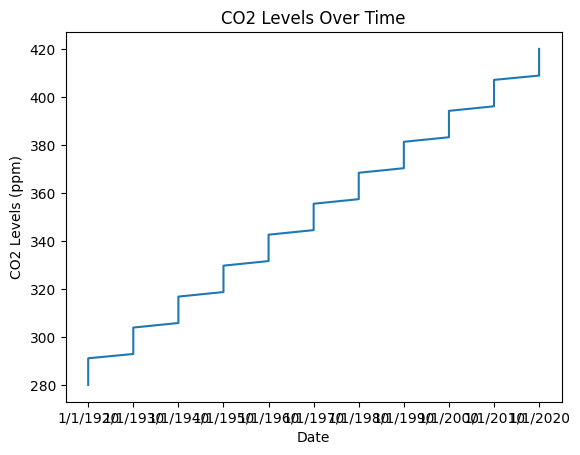

In [50]:
import matplotlib.pyplot as plt

# Assuming 'Year' is your time column and 'CO2' is a variable
plt.plot(df['Date'], df['CO2 Levels (ppm)'])
plt.xlabel('Date')
plt.ylabel('CO2 Levels (ppm)')
plt.title('CO2 Levels Over Time')
plt.show()

Index(['Date', 'Region', 'Avg Temp (°C)', 'CO2 Levels (ppm)', 'Sea Level (mm)',
       'Arctic Ice (M km²)', 'GHG Emissions (MtCO2eq)',
       'Deforestation (ha/yr)', 'Renewables (%)', 'Ocean Temp (°C)',
       'Precipitation (mm)', 'Extreme Events', 'Population (M)',
       'GDP/Capita (USD)', 'Energy (kWh/person)', 'CH4 (ppb)', 'N2O (ppb)',
       'Land Use (%)', 'Fossil Fuels (%)'],
      dtype='object')


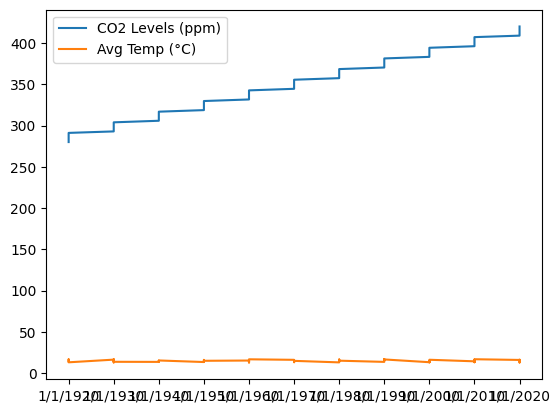

In [51]:
import matplotlib.pyplot as plt

# Check the actual column names in your DataFrame
print(df.columns)

# Assuming 'Year' is your time column and 'CO2' is a variable
plt.plot(df['Date'], df['CO2 Levels (ppm)'], label='CO2 Levels (ppm)')
# Replace 'Avg Temp (Â°C)' with the correct column name from your DataFrame
plt.plot(df['Date'], df['Avg Temp (°C)'], label='Avg Temp (°C)')  # Corrected column name
plt.legend()  # Add a legend to distinguish the lines
plt.show()

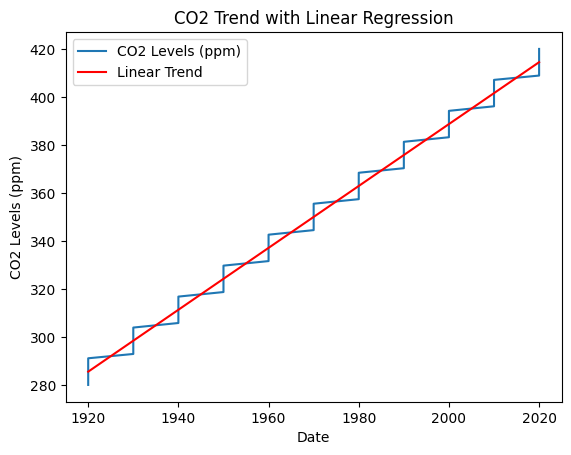

In [52]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd

# Assuming 'Date' is your time column and 'CO2' is the variable
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract numerical features from the datetime objects (e.g., ordinal)
X = df['Date'].apply(lambda date: date.toordinal()).values.reshape(-1, 1)
y = df['CO2 Levels (ppm)']

model = LinearRegression()
model.fit(X, y)

# Get the trend line
trend = model.predict(X)

# Plot the data and trend line
plt.plot(df['Date'], df['CO2 Levels (ppm)'], label='CO2 Levels (ppm)')
plt.plot(df['Date'], trend, label='Linear Trend', color='red')
plt.xlabel('Date')
plt.ylabel('CO2 Levels (ppm)')
plt.title('CO2 Trend with Linear Regression')
plt.legend()
plt.show()

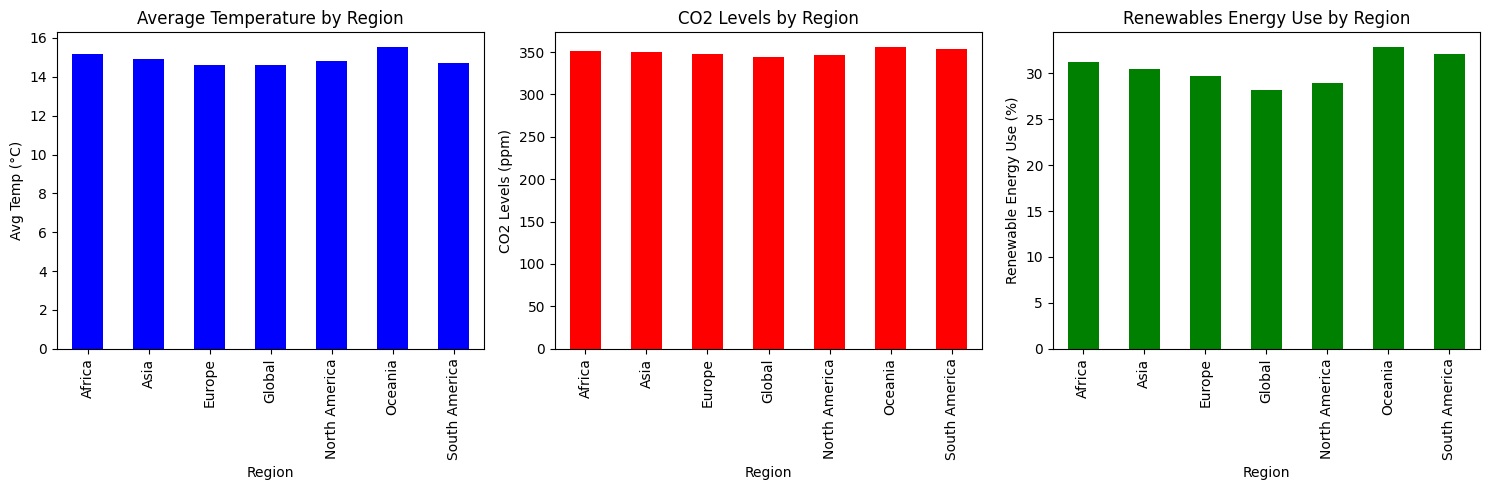

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and contains columns like 'Region', 'Avg Temp (°C)', 'CO2 Levels (ppm)', 'Renewable Energy Use (%)'

# Group data by region and calculate the mean for each variable
regional_data = df.groupby('Region')[['Avg Temp (°C)', 'CO2 Levels (ppm)', 'Renewables (%)']].mean()

# Create bar plots for comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns of plots

# Plot average temperature
regional_data['Avg Temp (°C)'].plot(kind='bar', ax=axes[0], color='blue')
axes[0].set_title('Average Temperature by Region')
axes[0].set_ylabel('Avg Temp (°C)')

# Plot CO2 levels
regional_data['CO2 Levels (ppm)'].plot(kind='bar', ax=axes[1], color='red')
axes[1].set_title('CO2 Levels by Region')
axes[1].set_ylabel('CO2 Levels (ppm)')

# Plot renewable energy usage
regional_data['Renewables (%)'].plot(kind='bar', ax=axes[2], color='green')
axes[2].set_title('Renewables Energy Use by Region')
axes[2].set_ylabel('Renewable Energy Use (%)')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

In [54]:
# Assuming your DataFrame is named 'df'
# Select only numeric columns before calculating correlation
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix for numerical columns
correlation_matrix = numerical_df.corr()

print(correlation_matrix)

                         Avg Temp (°C)  CO2 Levels (ppm)  Sea Level (mm)  \
Avg Temp (°C)                 1.000000          0.077797        0.077849   
CO2 Levels (ppm)              0.077797          1.000000        1.000000   
Sea Level (mm)                0.077849          1.000000        1.000000   
Arctic Ice (M km²)           -0.077885         -1.000000       -1.000000   
GHG Emissions (MtCO2eq)      -0.129674          0.038876        0.038828   
Deforestation (ha/yr)         0.142499          0.114029        0.114022   
Renewables (%)                0.077737          0.999999        0.999998   
Ocean Temp (°C)               0.034222         -0.045930       -0.046007   
Precipitation (mm)           -0.217932         -0.063603       -0.063346   
Extreme Events                0.217354          0.039423        0.039513   
Population (M)               -0.031805          0.095007        0.095065   
GDP/Capita (USD)              0.032142         -0.103746       -0.103651   
Energy (kWh/

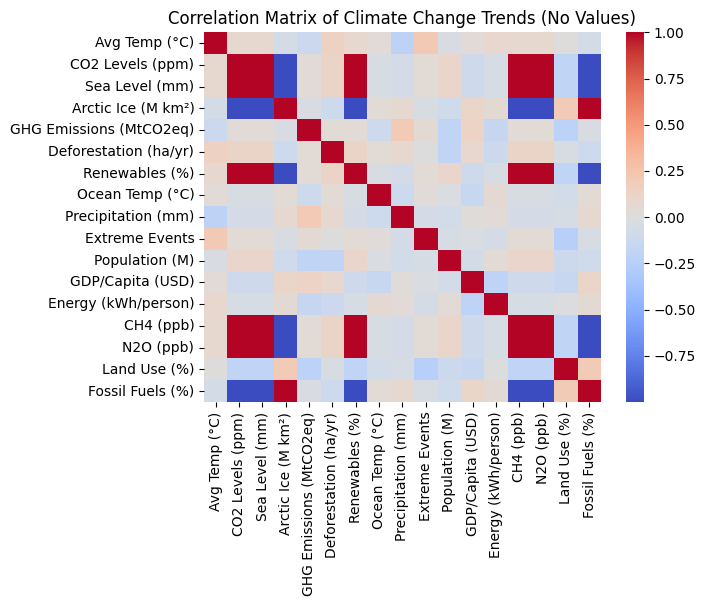

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

# ... (your previous code to calculate correlation_matrix) ...

sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")  # Set annot=False
plt.title('Correlation Matrix of Climate Change Trends (No Values)')
plt.show()

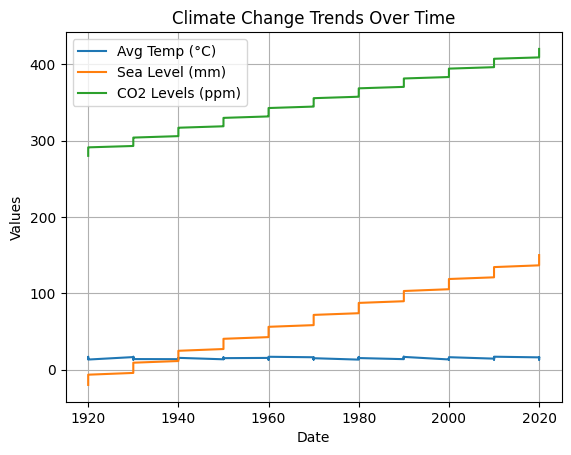

In [57]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and has columns like 'Date', 'Avg Temp (°C)', 'Sea Level (mm)', 'CO2 Levels (ppm)'

# Plot Temperature Trend
plt.plot(df['Date'], df['Avg Temp (°C)'], label='Avg Temp (°C)')

# Plot Sea Level Trend
plt.plot(df['Date'], df['Sea Level (mm)'], label='Sea Level (mm)')

# Plot CO2 Levels Trend
plt.plot(df['Date'], df['CO2 Levels (ppm)'], label='CO2 Levels (ppm)')

# Customize the plot
plt.xlabel('Date')
plt.ylabel('Values')
plt.title('Climate Change Trends Over Time')
plt.legend()  # Add a legend to distinguish lines
plt.grid(True)  # Add a grid for better readability (optional)
plt.show()

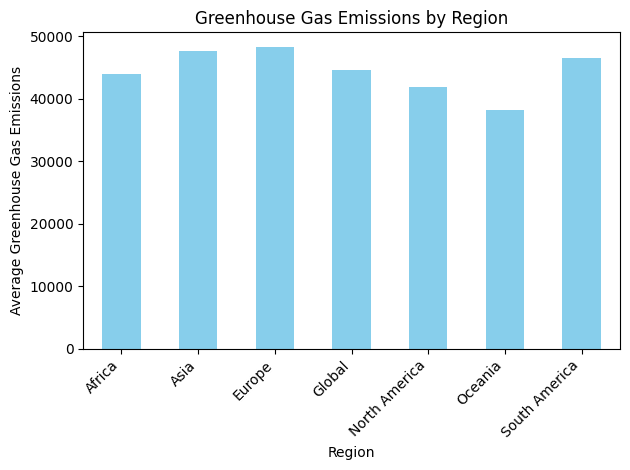

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and contains columns like 'Region', 'GHG Emissions (MtCO2eq)'

# Group data by region and calculate the mean emissions for each region
regional_emissions = df.groupby('Region')['GHG Emissions (MtCO2eq)'].mean()

# Create the bar plot
regional_emissions.plot(kind='bar', color='skyblue')

# Customize the plot
plt.xlabel('Region')
plt.ylabel('Average Greenhouse Gas Emissions')
plt.title('Greenhouse Gas Emissions by Region')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout for better spacing
plt.show()

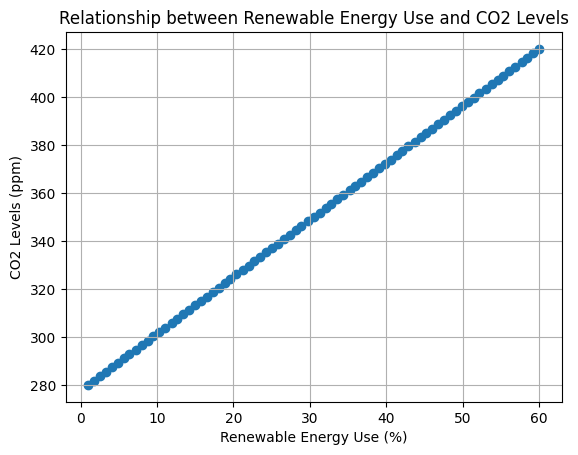

In [59]:
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and has columns like 'Renewables (%)', 'CO2 Levels (ppm)'

plt.scatter(df['Renewables (%)'], df['CO2 Levels (ppm)'])
plt.xlabel('Renewable Energy Use (%)')
plt.ylabel('CO2 Levels (ppm)')
plt.title('Relationship between Renewable Energy Use and CO2 Levels')
plt.grid(True)  # Optional: Add a grid for better readability
plt.show()

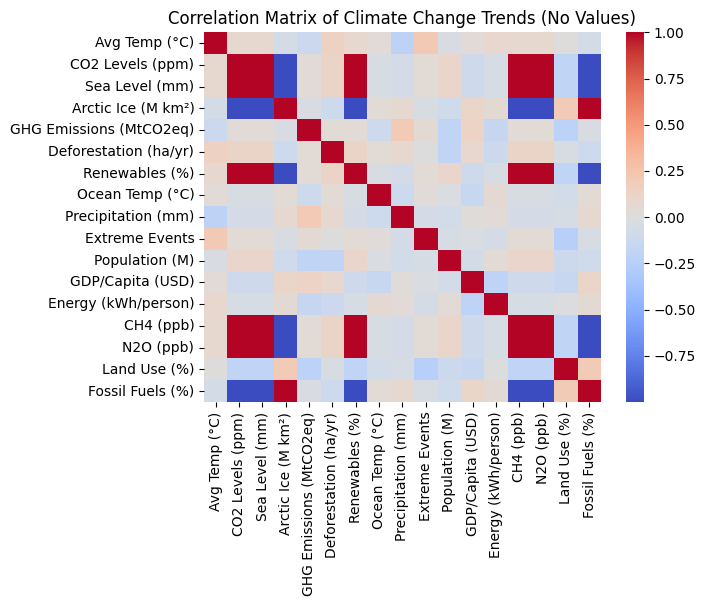

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df'
# Select only numeric columns before calculating correlation
numerical_df = df.select_dtypes(include=['number'])  # Changed to 'number' to select numeric types

# Calculate the correlation matrix for numerical columns
correlation_matrix = numerical_df.corr()

# Create the heatmap without annotations
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")  # Set annot=False
plt.title('Correlation Matrix of Climate Change Trends (No Values)')
plt.show()

<ipython-input-61-0ccea556b01d>:19: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_dates = pd.date_range(start=df['Date'].max(), periods=10, freq='Y') # Predict for next 10 years


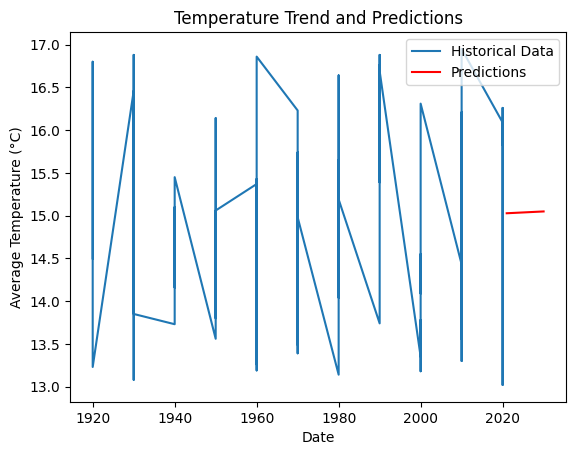

In [61]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'Date' is your time column and 'Avg Temp (°C)' is the target variable
# 1. Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 2. Extract numerical features from the datetime objects (e.g., ordinal)
X = df['Date'].apply(lambda date: date.toordinal()).values.reshape(-1, 1)
y = df['Avg Temp (°C)']

# 3. Create and train the model
model = LinearRegression()
model.fit(X, y)

# 4. Make predictions for future dates
future_dates = pd.date_range(start=df['Date'].max(), periods=10, freq='Y') # Predict for next 10 years
future_dates_ordinal = future_dates.to_series().apply(lambda date: date.toordinal()).values.reshape(-1, 1)
future_temps = model.predict(future_dates_ordinal)

# 5. Plot the historical data and predictions
plt.plot(df['Date'], df['Avg Temp (°C)'], label='Historical Data')
plt.plot(future_dates, future_temps, label='Predictions', color='red')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Temperature Trend and Predictions')
plt.legend()
plt.show()

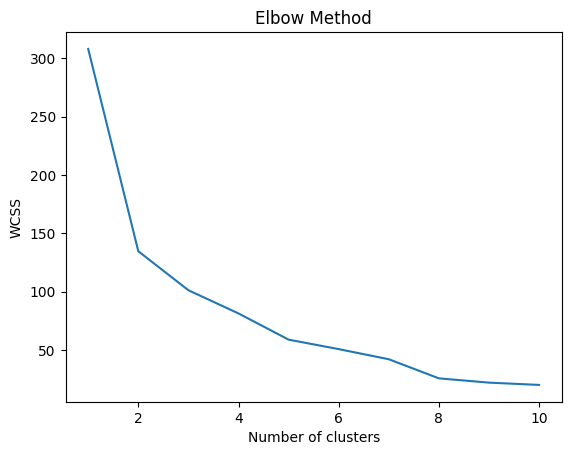

         Avg Temp (°C)  CO2 Levels (ppm)  Sea Level (mm)  Renewables (%)
Cluster                                                                 
0            14.805200        348.160000       62.764000       29.724000
1            15.137037        396.051852      120.922222       49.903704
2            14.762400        302.104000        6.840000       10.320000


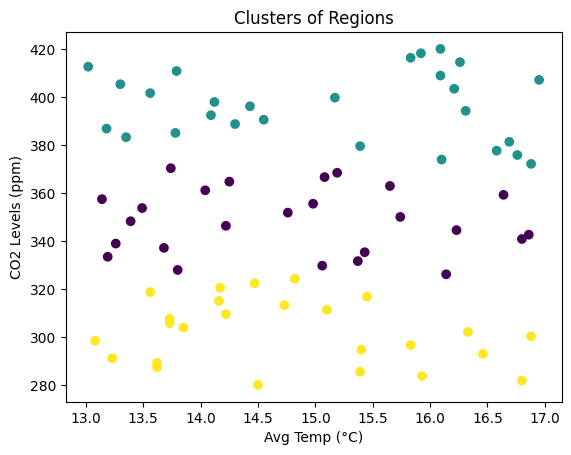

In [62]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Select relevant features for clustering
features = ['Avg Temp (°C)', 'CO2 Levels (ppm)', 'Sea Level (mm)', 'Renewables (%)']
X = df[features]

# 2. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Determine the optimal number of clusters (e.g., using the elbow method)
wcss = []
# Change the range to start from 1 and end at the number of samples or a smaller value
for i in range(1, min(11, X_scaled.shape[0] + 1)):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, min(11, X_scaled.shape[0] + 1)), wcss)  # Adjust the x-axis range
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# 4. Apply K-Means clustering with the chosen number of clusters
# (Let's assume we choose 3 clusters based on the elbow method)
# Choose a number of clusters less than or equal to the number of samples
n_clusters = min(3, X_scaled.shape[0])
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Analyze the clusters
print(df.groupby('Cluster')[features].mean())

# 6. Visualize the clusters (if possible with 2 or 3 features)
# (Example with 'Avg Temp (°C)' and 'CO2 Levels (ppm)')
plt.scatter(df['Avg Temp (°C)'], df['CO2 Levels (ppm)'], c=df['Cluster'], cmap='viridis')
plt.title('Clusters of Regions')
plt.xlabel('Avg Temp (°C)')
plt.ylabel('CO2 Levels (ppm)')
plt.show()

<ipython-input-63-0ccea556b01d>:19: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_dates = pd.date_range(start=df['Date'].max(), periods=10, freq='Y') # Predict for next 10 years


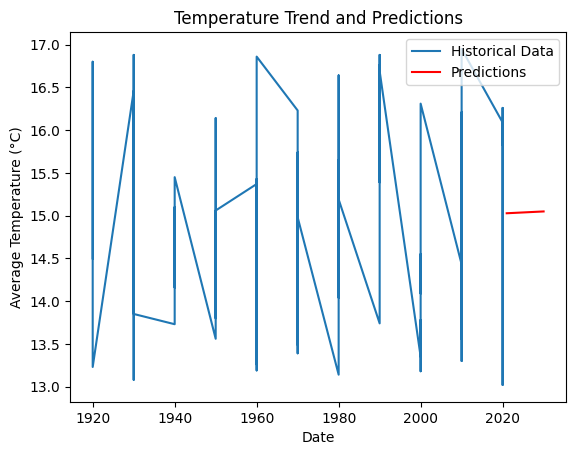

In [63]:
import numpy as np
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'Date' is your time column and 'Avg Temp (°C)' is the target variable
# 1. Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# 2. Extract numerical features from the datetime objects (e.g., ordinal)
X = df['Date'].apply(lambda date: date.toordinal()).values.reshape(-1, 1)
y = df['Avg Temp (°C)']

# 3. Create and train the model
model = LinearRegression()
model.fit(X, y)

# 4. Make predictions for future dates
future_dates = pd.date_range(start=df['Date'].max(), periods=10, freq='Y') # Predict for next 10 years
future_dates_ordinal = future_dates.to_series().apply(lambda date: date.toordinal()).values.reshape(-1, 1)
future_temps = model.predict(future_dates_ordinal)

# 5. Plot the historical data and predictions
plt.plot(df['Date'], df['Avg Temp (°C)'], label='Historical Data')
plt.plot(future_dates, future_temps, label='Predictions', color='red')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Temperature Trend and Predictions')
plt.legend()
plt.show()